In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
os.makedirs('../plots', exist_ok=True)


In [22]:
df = pd.read_csv('nyc_311_requests_jul2025_jun2026.csv')    
df.head()

,unique_key,created_date,closed_date,agency,complaint_type,descriptor,borough,incident_zip,status
0,65568225,2025-07-15T15:30:51.000,2025-07-31T14:14:57.000,DOHMH,Rodent,Rat Sighting,BROOKLYN,11219.0,Closed
1,65568932,2025-07-15T10:06:12.000,2025-07-15T10:51:29.000,NYPD,Illegal Parking,Commercial Overnight Parking,QUEENS,11692.0,Closed
2,65567550,2025-07-15T19:56:00.000,2025-07-15T21:01:00.000,DEP,Water System,Hydrant Running Full (WA4),QUEENS,11374.0,Closed
3,65567944,2025-07-15T08:24:53.000,2025-07-15T08:54:40.000,NYPD,Noise - Residential,Banging/Pounding,STATEN ISLAND,10306.0,Closed
4,65567116,2025-07-15T12:49:30.000,2025-07-22T14:28:31.000,DOT,Sidewalk Condition,Broken Sidewalk,MANHATTAN,10003.0,Closed


In [23]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17612 entries, 0 to 17611
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   unique_key      17612 non-null  int64  
 1   created_date    17612 non-null  object 
 2   closed_date     17160 non-null  object 
 3   agency          17612 non-null  object 
 4   complaint_type  17612 non-null  object 
 5   descriptor      17191 non-null  object 
 6   borough         17612 non-null  object 
 7   incident_zip    17499 non-null  float64
 8   status          17612 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 1.2+ MB


(17612, 9)

In [24]:
df.isna().sum()

unique_key          0
created_date        0
closed_date       452
agency              0
complaint_type      0
descriptor        421
borough             0
incident_zip      113
status              0
dtype: int64

In [25]:
df.duplicated().sum()

np.int64(0)

In [26]:
df['borough'].value_counts()

borough
BROOKLYN         5377
QUEENS           4428
BRONX            3602
MANHATTAN        3594
STATEN ISLAND     601
Unspecified        10
Name: count, dtype: int64

In [27]:
# Quick scan of every text column at once
for col in df.select_dtypes(include='object').columns:
    print(col, df[col].unique()[:15], '\n')

created_date ['2025-07-15T15:30:51.000' '2025-07-15T10:06:12.000'
 '2025-07-15T19:56:00.000' '2025-07-15T08:24:53.000'
 '2025-07-15T12:49:30.000' '2025-07-15T18:07:24.000'
 '2025-07-15T08:13:51.000' '2025-07-15T20:56:51.000'
 '2025-07-15T10:20:13.000' '2025-07-14T12:32:49.000'
 '2025-07-15T18:33:45.000' '2025-07-15T13:50:00.000'
 '2025-07-15T18:55:00.000' '2025-07-15T18:22:27.000'
 '2025-07-15T17:52:41.000'] 

closed_date ['2025-07-31T14:14:57.000' '2025-07-15T10:51:29.000'
 '2025-07-15T21:01:00.000' '2025-07-15T08:54:40.000'
 '2025-07-22T14:28:31.000' '2025-07-16T05:23:29.000'
 '2025-08-06T00:00:00.000' '2025-07-15T21:27:30.000'
 '2025-07-15T14:18:06.000' '2025-07-14T17:30:30.000' nan
 '2025-07-15T13:50:00.000' '2025-07-18T14:38:00.000'
 '2025-07-15T18:44:11.000' '2025-07-16T00:00:00.000'] 

agency ['DOHMH' 'NYPD' 'DEP' 'DOT' 'DSNY' 'DPR' 'DOB' 'TLC' 'DHS' 'DCWP' 'EDC'
 'HPD' 'OOS' 'DOE' 'NYC311-PRD'] 

complaint_type ['Rodent' 'Illegal Parking' 'Water System' 'Noise - Residential'
 '

In [28]:
# convert dates from text to datetime
df['created_date'] = pd.to_datetime(df['created_date'])
df['closed_date'] = pd.to_datetime(df['closed_date'])
df.head()

,unique_key,created_date,closed_date,agency,complaint_type,descriptor,borough,incident_zip,status
0,65568225,2025-07-15 15:30:51,2025-07-31 14:14:57,DOHMH,Rodent,Rat Sighting,BROOKLYN,11219.0,Closed
1,65568932,2025-07-15 10:06:12,2025-07-15 10:51:29,NYPD,Illegal Parking,Commercial Overnight Parking,QUEENS,11692.0,Closed
2,65567550,2025-07-15 19:56:00,2025-07-15 21:01:00,DEP,Water System,Hydrant Running Full (WA4),QUEENS,11374.0,Closed
3,65567944,2025-07-15 08:24:53,2025-07-15 08:54:40,NYPD,Noise - Residential,Banging/Pounding,STATEN ISLAND,10306.0,Closed
4,65567116,2025-07-15 12:49:30,2025-07-22 14:28:31,DOT,Sidewalk Condition,Broken Sidewalk,MANHATTAN,10003.0,Closed


In [29]:
# ZIP: float -> 5-char string
df['incident_zip'] = df['incident_zip'].astype('Int64').astype('string').str.zfill(5)
df.head()

,unique_key,created_date,closed_date,agency,complaint_type,descriptor,borough,incident_zip,status
0,65568225,2025-07-15 15:30:51,2025-07-31 14:14:57,DOHMH,Rodent,Rat Sighting,BROOKLYN,11219,Closed
1,65568932,2025-07-15 10:06:12,2025-07-15 10:51:29,NYPD,Illegal Parking,Commercial Overnight Parking,QUEENS,11692,Closed
2,65567550,2025-07-15 19:56:00,2025-07-15 21:01:00,DEP,Water System,Hydrant Running Full (WA4),QUEENS,11374,Closed
3,65567944,2025-07-15 08:24:53,2025-07-15 08:54:40,NYPD,Noise - Residential,Banging/Pounding,STATEN ISLAND,10306,Closed
4,65567116,2025-07-15 12:49:30,2025-07-22 14:28:31,DOT,Sidewalk Condition,Broken Sidewalk,MANHATTAN,10003,Closed


In [30]:
# Turn disguised missing values into real NaN
df['borough'] = df['borough'].replace('Unspecified', pd.NA)
df['descriptor'] = df['descriptor'].replace('N/A', pd.NA)
df['status'] = df['status'].replace('Unspecified', pd.NA)
df.head()   


,unique_key,created_date,closed_date,agency,complaint_type,descriptor,borough,incident_zip,status
0,65568225,2025-07-15 15:30:51,2025-07-31 14:14:57,DOHMH,Rodent,Rat Sighting,BROOKLYN,11219,Closed
1,65568932,2025-07-15 10:06:12,2025-07-15 10:51:29,NYPD,Illegal Parking,Commercial Overnight Parking,QUEENS,11692,Closed
2,65567550,2025-07-15 19:56:00,2025-07-15 21:01:00,DEP,Water System,Hydrant Running Full (WA4),QUEENS,11374,Closed
3,65567944,2025-07-15 08:24:53,2025-07-15 08:54:40,NYPD,Noise - Residential,Banging/Pounding,STATEN ISLAND,10306,Closed
4,65567116,2025-07-15 12:49:30,2025-07-22 14:28:31,DOT,Sidewalk Condition,Broken Sidewalk,MANHATTAN,10003,Closed


In [31]:
# data-entry error check: closed before created?
bad_dates = df[df['closed_date'] < df['created_date']]
len(bad_dates)
bad_dates

,unique_key,created_date,closed_date,agency,complaint_type,descriptor,borough,incident_zip,status
6143,66689505,2025-11-02 01:31:42,2025-11-02 01:06:29,NYPD,Noise - Residential,Banging/Pounding,BROOKLYN,11233,Closed
6211,66686797,2025-11-02 01:22:33,2025-11-02 01:02:52,NYPD,Noise - Residential,Loud Music/Party,BROOKLYN,11222,Closed
6289,66691905,2025-11-02 01:43:01,2025-11-02 01:05:10,DSNY,Commercial Disposal Complaint,Waste Disposal,QUEENS,11103,Closed
6358,66686844,2025-11-02 01:46:37,2025-11-02 01:13:13,NYPD,Noise - Residential,Loud Music/Party,MANHATTAN,10025,Closed
6382,66690845,2025-11-02 01:49:32,2025-11-02 01:16:28,NYPD,Noise - Commercial,Banging/Pounding,QUEENS,11361,Closed
6504,66687706,2025-11-02 01:30:37,2025-11-02 01:10:25,NYPD,Illegal Parking,Blocked Hydrant,BROOKLYN,11205,Closed


In [32]:
#  feature engineering
df['resolution_hours'] = (df['closed_date'] - df['created_date']).dt.total_seconds() / 3600
df['month'] = df['created_date'].dt.to_period('M')
df['day_of_week'] = df['created_date'].dt.day_name()
df['hour'] = df['created_date'].dt.hour
df['is_closed'] = df['closed_date'].notna()
df.head(10)

,unique_key,created_date,closed_date,agency,complaint_type,descriptor,borough,incident_zip,status,resolution_hours,month,day_of_week,hour,is_closed
0,65568225,2025-07-15 15:30:51,2025-07-31 14:14:57,DOHMH,Rodent,Rat Sighting,BROOKLYN,11219,Closed,382.735000,2025-07,Tuesday,15,True
1,65568932,2025-07-15 10:06:12,2025-07-15 10:51:29,NYPD,Illegal Parking,Commercial Overnight Parking,QUEENS,11692,Closed,0.754722,2025-07,Tuesday,10,True
2,65567550,2025-07-15 19:56:00,2025-07-15 21:01:00,DEP,Water System,Hydrant Running Full (WA4),QUEENS,11374,Closed,1.083333,2025-07,Tuesday,19,True
3,65567944,2025-07-15 08:24:53,2025-07-15 08:54:40,NYPD,Noise - Residential,Banging/Pounding,STATEN ISLAND,10306,Closed,0.496389,2025-07,Tuesday,8,True
4,65567116,2025-07-15 12:49:30,2025-07-22 14:28:31,DOT,Sidewalk Condition,Broken Sidewalk,MANHATTAN,10003,Closed,169.650278,2025-07,Tuesday,12,True
5,65567042,2025-07-15 18:07:24,2025-07-16 05:23:29,NYPD,Illegal Parking,Blocked Hydrant,QUEENS,11421,Closed,11.268056,2025-07,Tuesday,18,True
6,65564084,2025-07-15 08:13:51,2025-08-06 00:00:00,DSNY,Graffiti,Graffiti,BRONX,10452,Closed,519.769167,2025-07,Tuesday,8,True
7,65568917,2025-07-15 20:56:51,2025-07-15 21:27:30,NYPD,Illegal Parking,Blocked Sidewalk,BROOKLYN,11205,Closed,0.510833,2025-07,Tuesday,20,True
8,65564336,2025-07-15 10:20:13,2025-07-15 14:18:06,NYPD,Illegal Parking,Parking Permit Improper Use,MANHATTAN,10039,Closed,3.964722,2025-07,Tuesday,10,True
9,65561670,2025-07-14 12:32:49,2025-07-14 17:30:30,NYPD,Illegal Parking,Double Parked Blocking Traffic,QUEENS,11378,Closed,4.961389,2025-07,Monday,12,True


In [33]:
df.info()
df['resolution_hours'].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17612 entries, 0 to 17611
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   unique_key        17612 non-null  int64         
 1   created_date      17612 non-null  datetime64[ns]
 2   closed_date       17160 non-null  datetime64[ns]
 3   agency            17612 non-null  object        
 4   complaint_type    17612 non-null  object        
 5   descriptor        17191 non-null  object        
 6   borough           17602 non-null  object        
 7   incident_zip      17499 non-null  string        
 8   status            17611 non-null  object        
 9   resolution_hours  17160 non-null  float64       
 10  month             17612 non-null  period[M]     
 11  day_of_week       17612 non-null  object        
 12  hour              17612 non-null  int32         
 13  is_closed         17612 non-null  bool          
dtypes: bool(1), datetime64

count    17160.000000
mean       102.833124
std        454.024565
min         -0.630833
25%          0.572917
50%          1.903750
75%         14.036250
max       7965.957222
Name: resolution_hours, dtype: float64

In [34]:
df.loc[df['resolution_hours'] < 0, 'resolution_hours'] = pd.NA

In [35]:
# how many DST casualties were there?
df['resolution_hours'].isna().sum() - (~df['is_closed']).sum()

np.int64(6)

In [36]:
df.describe()

,unique_key,created_date,closed_date,resolution_hours,hour
count,1.761200e+04,17612,17160,17154.000000,17612.000000
mean,6.736489e+07,2025-12-25 01:53:47.857653760,2025-12-28 09:54:16.596445440,102.869257,12.123893
min,5.650291e+07,2025-07-01 00:00:23,2025-07-01 00:06:57,0.000000,0.000000
25%,6.632450e+07,2025-10-01 00:04:07.750000128,2025-10-01 01:46:06.750000128,0.573611,1.000000
50%,6.734526e+07,2026-01-01 00:04:18.500000,2026-01-01 01:01:21.500000,1.906667,14.000000
75%,6.852321e+07,2026-04-01 00:00:13,2026-04-01 11:50:17.750000128,14.045000,21.000000
max,6.957295e+07,2026-06-30 22:57:11,2026-07-02 19:13:38,7965.957222,23.000000
std,1.281982e+06,NaN,NaN,454.099853,8.878653


In [37]:
# save the cleaned dataset — analysis never overwrites raw data
df.to_csv('../Analysis with Python/nyc_311_clean.csv', index=False)

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

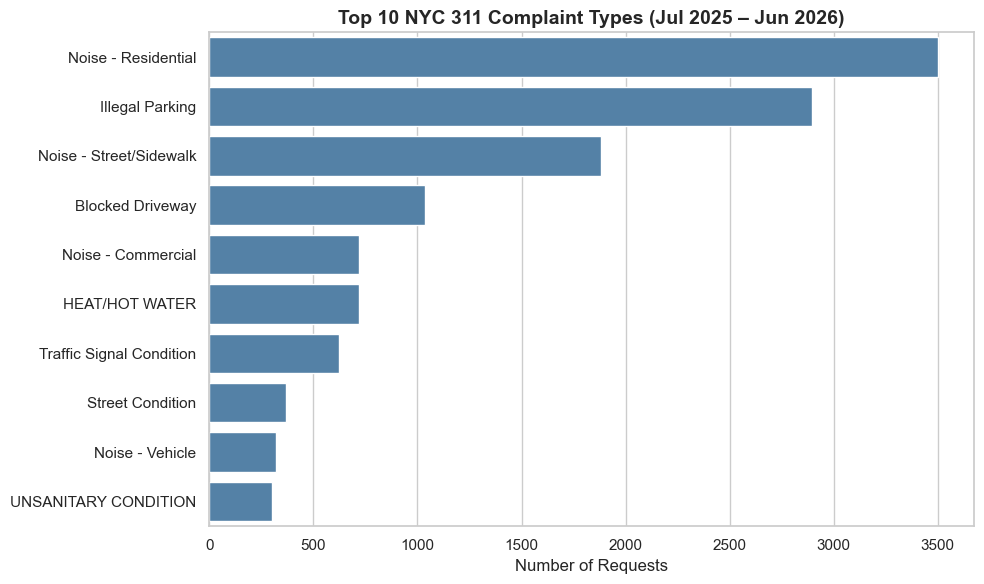

In [39]:
top10 = df['complaint_type'].value_counts().head(10)

ax = sns.barplot(x=top10.values, y=top10.index, color='steelblue')
ax.set_title('Top 10 NYC 311 Complaint Types (Jul 2025 – Jun 2026)')
ax.set_xlabel('Number of Requests')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../plots/01_top_complaints.png', dpi=150, bbox_inches='tight')
plt.show()

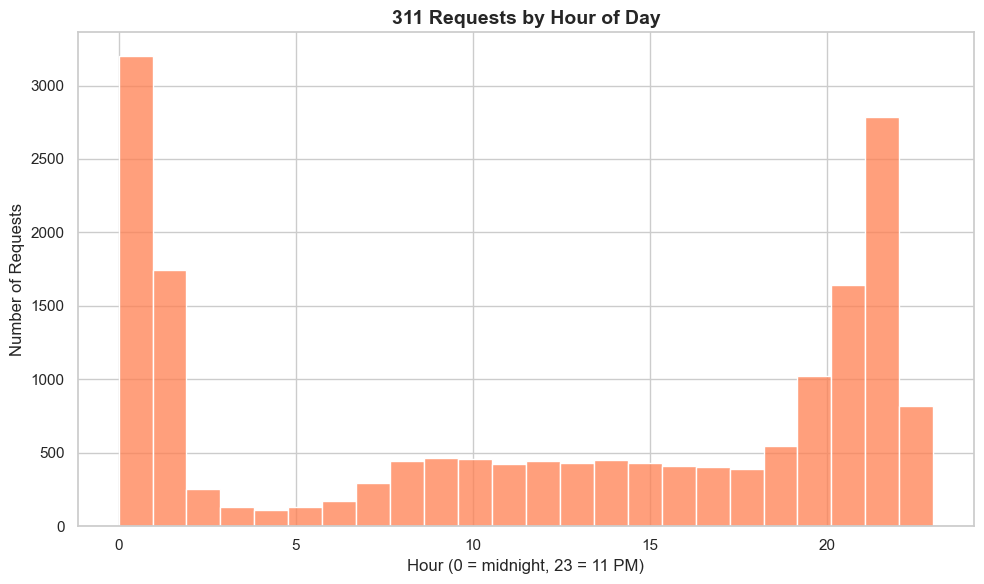

In [40]:
ax = sns.histplot(df['hour'], bins=24, color='coral')
ax.set_title('311 Requests by Hour of Day')
ax.set_xlabel('Hour (0 = midnight, 23 = 11 PM)')
ax.set_ylabel('Number of Requests')
plt.tight_layout()
plt.savefig('../plots/02_requests_by_hour.png', dpi=150, bbox_inches='tight')
plt.show()

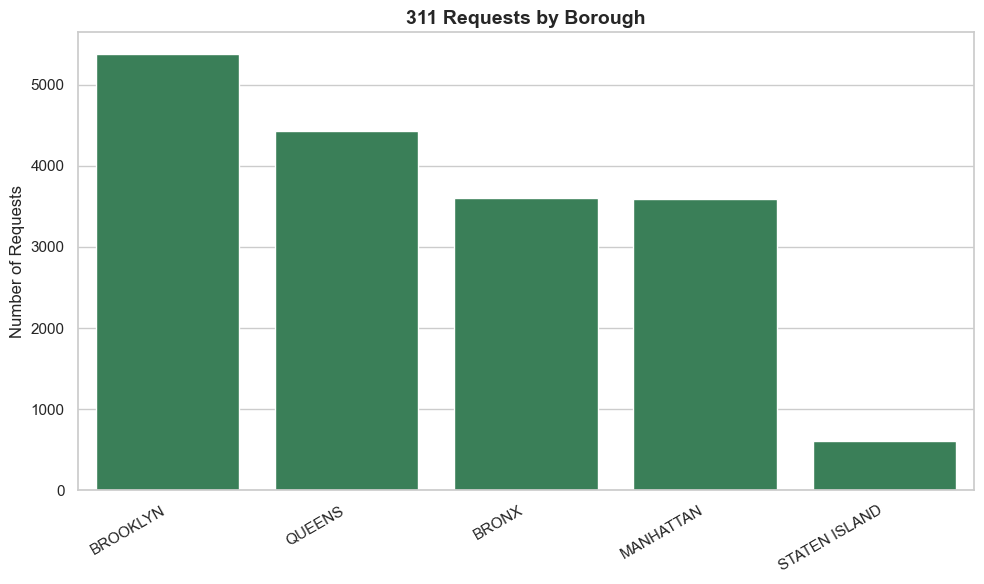

In [41]:
borough_counts = df['borough'].value_counts()

ax = sns.barplot(x=borough_counts.index, y=borough_counts.values, color='seagreen')
ax.set_title('311 Requests by Borough')
ax.set_xlabel('')
ax.set_ylabel('Number of Requests')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('../plots/03_requests_by_borough.png', dpi=150, bbox_inches='tight')
plt.show()

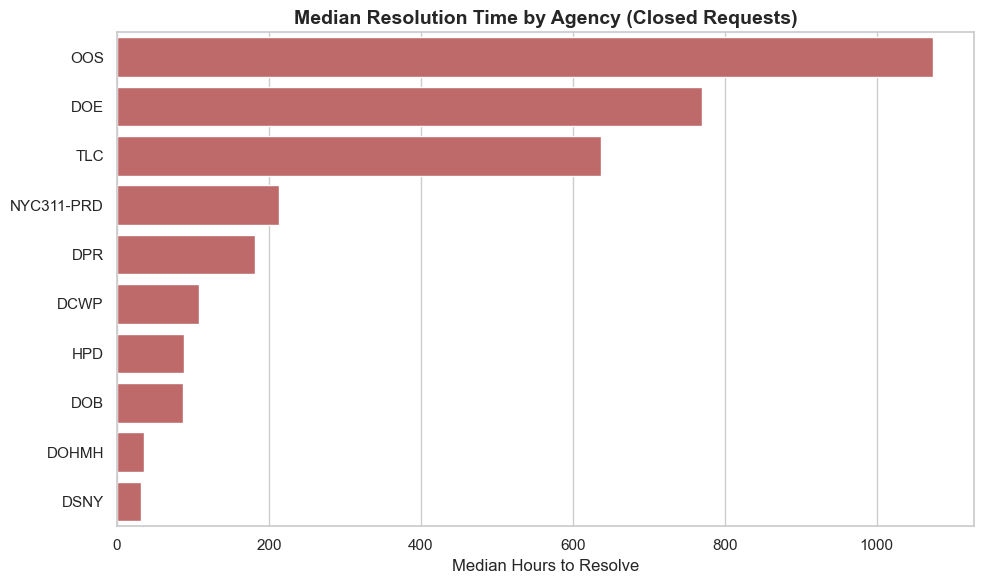

In [42]:
agency_speed = (
    df[df['is_closed']]
    .groupby('agency')['resolution_hours']
    .median()
    .sort_values(ascending=False)
    .head(10)
)

ax = sns.barplot(x=agency_speed.values, y=agency_speed.index, color='indianred')
ax.set_title('Median Resolution Time by Agency (Closed Requests)')
ax.set_xlabel('Median Hours to Resolve')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../plots/04_agency_resolution_time.png', dpi=150, bbox_inches='tight')
plt.show()

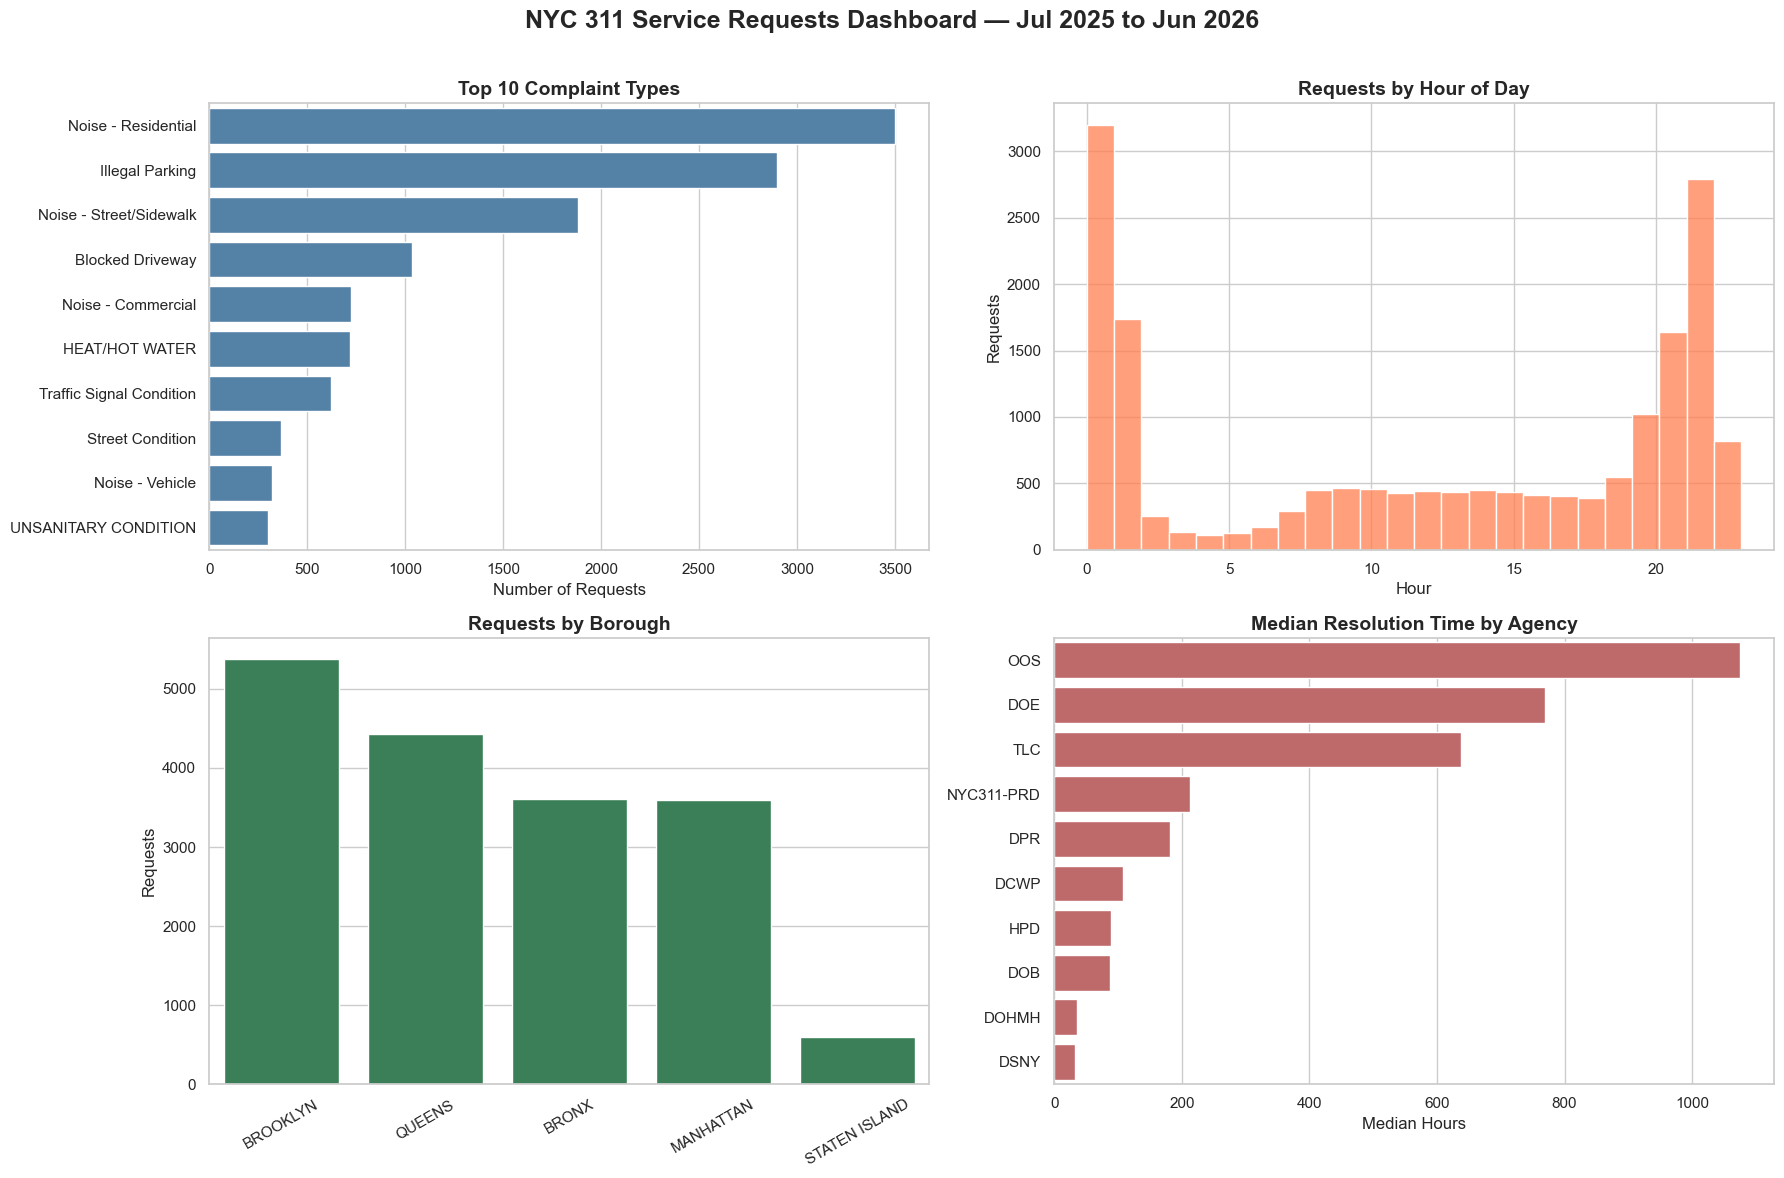

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('NYC 311 Service Requests Dashboard — Jul 2025 to Jun 2026',
             fontsize=18, fontweight='bold')

# Top-left: top complaints
top10 = df['complaint_type'].value_counts().head(10)
sns.barplot(x=top10.values, y=top10.index, color='steelblue', ax=axes[0, 0])
axes[0, 0].set_title('Top 10 Complaint Types')
axes[0, 0].set_xlabel('Number of Requests'); axes[0, 0].set_ylabel('')

# Top-right: by hour
sns.histplot(df['hour'], bins=24, color='coral', ax=axes[0, 1])
axes[0, 1].set_title('Requests by Hour of Day')
axes[0, 1].set_xlabel('Hour'); axes[0, 1].set_ylabel('Requests')

# Bottom-left: by borough
bc = df['borough'].value_counts()
sns.barplot(x=bc.index, y=bc.values, color='seagreen', ax=axes[1, 0])
axes[1, 0].set_title('Requests by Borough')
axes[1, 0].set_xlabel(''); axes[1, 0].set_ylabel('Requests')
axes[1, 0].tick_params(axis='x', rotation=30)

# Bottom-right: agency speed
sns.barplot(x=agency_speed.values, y=agency_speed.index, color='indianred', ax=axes[1, 1])
axes[1, 1].set_title('Median Resolution Time by Agency')
axes[1, 1].set_xlabel('Median Hours'); axes[1, 1].set_ylabel('')

plt.tight_layout(rect=[0, 0, 1, 0.97])  # leave room for the suptitle
plt.savefig('../plots/05_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()